In [1]:
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
from keras.datasets import mnist

In [2]:
# load MNIST dataset
(trainImg, trainLabel), (testImg, testLabel) = mnist.load_data()
print("MNIST:", trainImg.shape, testImg.shape)

MNIST: (60000, 28, 28) (10000, 28, 28)


In [3]:
# combine training and test data
all_images = np.concatenate([trainImg, testImg], axis=0)
all_labels = np.concatenate([trainLabel, testLabel], axis=0)

print("combined dataset:", all_images.shape, all_labels.shape)

combined dataset: (70000, 28, 28) (70000,)


In [4]:
def minMaxScaling(img):
    img = img.astype(np.float32)
    return cv2.normalize(img, None, alpha=0, beta=1, norm_type=cv2.NORM_MINMAX)

In [5]:
# clean the data（MinMax scaling）
clean_images = np.array([minMaxScaling(img) for img in all_images])
clean_labels = all_labels.copy()

print("data after cleaning:", clean_images.shape, clean_labels.shape)

data after cleaning: (70000, 28, 28) (70000,)


In [6]:
from sklearn.model_selection import train_test_split

# divide new training and test dataset, using the ratio of 8:2
X_train, X_test, y_train, y_test = train_test_split(
    clean_images, clean_labels, test_size=0.2, random_state=42, shuffle=True
)

print("training_data:", X_train.shape, y_train.shape)
print("testing_data:", X_test.shape, y_test.shape)

training_data: (56000, 28, 28) (56000,)
testing_data: (14000, 28, 28) (14000,)


In [7]:
unique_train, counts_train = np.unique(y_train, return_counts=True)
unique_test, counts_test = np.unique(y_test, return_counts=True)

print("Train distribution:", dict(zip(unique_train, counts_train)))
print("Test distribution:", dict(zip(unique_test, counts_test)))

Train distribution: {0: 5560, 1: 6277, 2: 5610, 3: 5708, 4: 5529, 5: 5040, 6: 5480, 7: 5790, 8: 5468, 9: 5538}
Test distribution: {0: 1343, 1: 1600, 2: 1380, 3: 1433, 4: 1295, 5: 1273, 6: 1396, 7: 1503, 8: 1357, 9: 1420}


In [8]:
import tensorflow as tf

data_augmentation = tf.keras.Sequential([
    
    # tf.keras.layers.RandomFlip("horizontal")
    # Random horizontal flip is removed because MNIST digits are symmetric-sensitive.
    # If flipped, digits like 2, 5, and 7 might become unrecognizable or ambiguous.

    tf.keras.layers.RandomRotation(0.05),           # Slight rotation (too large rotation makes 6 and 9 easily misinterpretable)
    tf.keras.layers.RandomTranslation(0.05, 0.05),  # Apply slight pixel shifting.
    tf.keras.layers.RandomZoom(0.05),               # Small zoom ensures the digit remains readable.
])


In [9]:
# MNIST grayscale → add channel dimensio
X_train_tf = X_train[..., np.newaxis]
X_test_tf = X_test[..., np.newaxis]

print("training dataset before enrichment:", X_train_tf.shape)

training dataset before enrichment: (56000, 28, 28, 1)


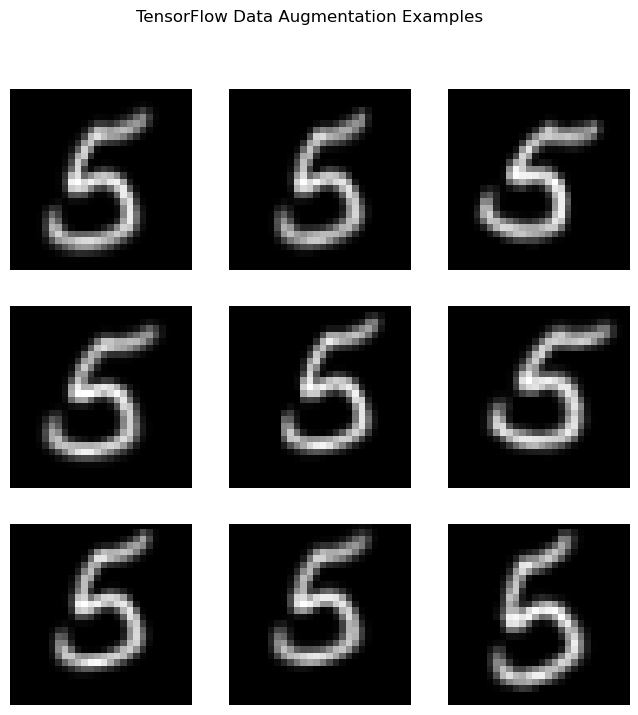

In [10]:
# Select one image for demonstration
sample = X_train_tf[0]

plt.figure(figsize=(8, 8))

for i in range(9):
    augmented = data_augmentation(tf.expand_dims(sample, 0))  # expand the latitude to (batch, h, w, c)
    plt.subplot(3, 3, i+1)
    plt.imshow(augmented[0, :, :, 0], cmap="gray")
    plt.axis("off")

plt.suptitle("TensorFlow Data Augmentation Examples")
plt.show()

In [11]:
model = tf.keras.Sequential([
    data_augmentation,                            # Data augmentation layer (online augmentation)

    tf.keras.layers.Conv2D(32, 3, activation='relu'),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(64, 3, activation='relu'),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(10, activation='softmax'),
])

In [12]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    X_train_tf, y_train,
    epochs=10,
    validation_data=(X_test_tf, y_test),
    batch_size=64
)

Epoch 1/10


875/875 [==============================] - 87s 92ms/step - loss: 0.2941 - accuracy: 0.9105 - val_loss: 0.0871 - val_accuracy: 0.9746
Epoch 2/10
875/875 [==============================] - 81s 92ms/step - loss: 0.1047 - accuracy: 0.9681 - val_loss: 0.0554 - val_accuracy: 0.9836
Epoch 3/10
875/875 [==============================] - 79s 90ms/step - loss: 0.0769 - accuracy: 0.9768 - val_loss: 0.0448 - val_accuracy: 0.9859
Epoch 4/10
875/875 [==============================] - 82s 94ms/step - loss: 0.0649 - accuracy: 0.9806 - val_loss: 0.0393 - val_accuracy: 0.9872
Epoch 5/10
875/875 [==============================] - 81s 92ms/step - loss: 0.0590 - accuracy: 0.9811 - val_loss: 0.0357 - val_accuracy: 0.9898
Epoch 6/10
875/875 [==============================] - 79s 90ms/step - loss: 0.0495 - accuracy: 0.9848 - val_loss: 0.0339 - val_accuracy: 0.9904
Epoch 7/10
875/875 [==============================] - 79s 91ms/step - loss: 0.0441 - accuracy: 0.9863 - val_loss: 0.0360 - val_accuracy: 0.9890
Epo

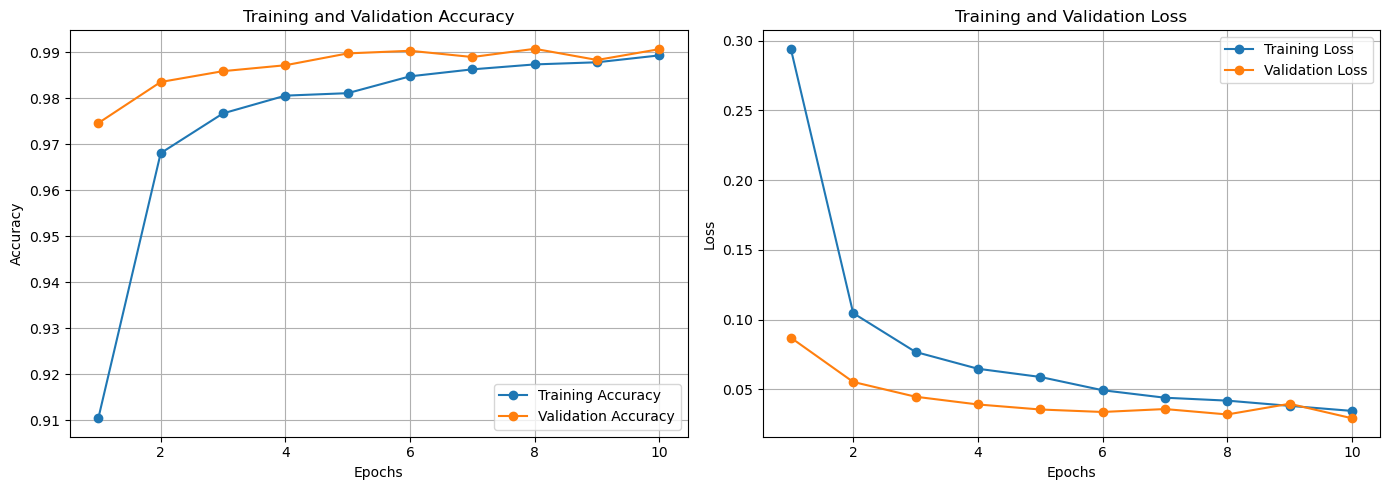

In [13]:
# Plot Accuracy and Loss curves
history_dict = history.history  # Training history returned from model.fit()

acc = history_dict['accuracy']                # Training accuracy
val_acc = history_dict['val_accuracy']        # Validation accuracy
loss = history_dict['loss']                   # Training loss
val_loss = history_dict['val_loss']           # Validation loss

epochs = range(1, len(acc) + 1)
plt.figure(figsize=(14, 5))

# Accuracy curve
plt.subplot(1, 2, 1)
plt.plot(epochs, acc, marker='o', label='Training Accuracy')
plt.plot(epochs, val_acc, marker='o', label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.grid(True)
plt.legend()

# Loss curve
plt.subplot(1, 2, 2)
plt.plot(epochs, loss, marker='o', label='Training Loss')
plt.plot(epochs, val_loss, marker='o', label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

In [14]:
# Build model WITHOUT augmentation
model_no_aug = tf.keras.Sequential([
    tf.keras.layers.Rescaling(1./255, input_shape=(28,28,1)),  # normalize only — no augmentation

    tf.keras.layers.Conv2D(32, 3, activation='relu'),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(64, 3, activation='relu'),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(10, activation='softmax')
])

model_no_aug.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_no_aug = model_no_aug.fit(
    X_train[...,None],  # add channel dim
    y_train,
    epochs=10,
    batch_size=64,
    validation_data=(X_test[...,None], y_test)
)

Epoch 1/10
875/875 [==============================] - 61s 70ms/step - loss: 0.9052 - accuracy: 0.7051 - val_loss: 0.3544 - val_accuracy: 0.8974
Epoch 2/10
875/875 [==============================] - 61s 70ms/step - loss: 0.2681 - accuracy: 0.9183 - val_loss: 0.2227 - val_accuracy: 0.9341
Epoch 3/10
875/875 [==============================] - 61s 69ms/step - loss: 0.1820 - accuracy: 0.9442 - val_loss: 0.1622 - val_accuracy: 0.9511
Epoch 4/10
875/875 [==============================] - 61s 70ms/step - loss: 0.1411 - accuracy: 0.9565 - val_loss: 0.1359 - val_accuracy: 0.9594
Epoch 5/10
875/875 [==============================] - 61s 70ms/step - loss: 0.1162 - accuracy: 0.9642 - val_loss: 0.1150 - val_accuracy: 0.9637
Epoch 6/10
875/875 [==============================] - 61s 70ms/step - loss: 0.1000 - accuracy: 0.9687 - val_loss: 0.1113 - val_accuracy: 0.9650
Epoch 7/10
875/875 [==============================] - 62s 70ms/step - loss: 0.0883 - accuracy: 0.9719 - val_loss: 0.0971 - val_accuracy:

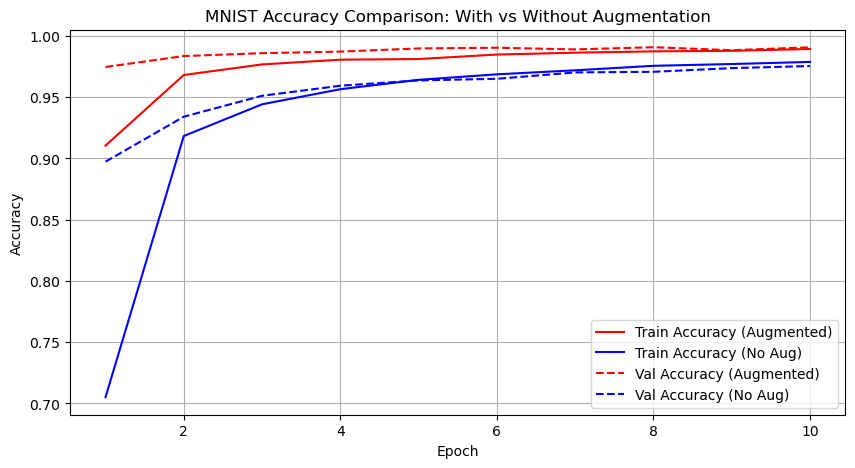

In [15]:
# Extract accuracy curves
acc_aug = history.history['accuracy']              # Train (Aug)
val_acc_aug = history.history['val_accuracy']      # Val (Aug)

acc_no = history_no_aug.history['accuracy']        # Train (No Aug)
val_acc_no = history_no_aug.history['val_accuracy']# Val (No Aug)

epochs = range(1, len(acc_aug) + 1)   # epoch count based on augmented model


# Plot comparison figure
plt.figure(figsize=(10,5))

# ---- Train Accuracy ----
plt.plot(epochs, acc_aug, 'r-', label='Train Accuracy (Augmented)')
plt.plot(epochs, acc_no, 'b-', label='Train Accuracy (No Aug)')

# ---- Validation Accuracy ----
plt.plot(epochs, val_acc_aug, 'r--', label='Val Accuracy (Augmented)')
plt.plot(epochs, val_acc_no, 'b--', label='Val Accuracy (No Aug)')

plt.title("MNIST Accuracy Comparison: With vs Without Augmentation")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.grid(True)
plt.legend()
plt.show()

With TensorFlow augmentation, MNIST validation accuracy rose from 97% to 99%, showing only slight improvement.
Probably because MNIST is simple and already easily separable, so even basic CNN learns well.